# Bayesian Validation Results IV. Galactic Plus Extragalactic Foregrounds and Airy Beam Width Perturbations
*ValSKA provides a reproducible, open-source framework for assessing the impact of beam‐FWHM uncertainty on 21-cm power spectrum inference*

## Overview  
This notebook presents the pyuvsim, Galactic (GSM) + extragalactic (GLEAM) foreground validation results of the **ValSKA** package, assuming an Airy primary beam pattern. The goals are:  
- Demonstrate how the pipeline verifies the sensitivity of 21-cm power spectrum forward models to errors in the instrument’s primary‐beam width modelling.  
- Provide a reproducible analysis workflow from chain outputs to key summary figures and statistics.  
- Interpret the results for stakeholders (including instrument teams, pipeline developers, and science leads).

### Usage  
1. Ensure the Airy sweep chain outputs exist and your path manager points to them (`get_default_path_manager()`).  
2. Ensure the sweep report summary exists at `.../_sweeps/sweep_airy_init/report/sweep_report_summary.json` (for example by running `valska-bayeseor-report-all` for this sweep).  
3. Run notebook cells in sequence to compute Bayes factors and generate all figures directly from data/code.  
4. Inspect the generated figures and BaNTER summary to determine whether each beam-width perturbation passes or fails validation.

### Expected Audience  
- Instrument/data-analysis/astrophysical-inference scientists working in 21-cm cosmology and the wider precision radio astronomy community  
- Software developers building forward-modelling and inference pipelines  
- STFC / UKSRC project leads reviewing validation status  


## Imports  
Load the required modules from **ValSKA** for plotting, chain handling and Bayesian evidence computation.


In [2]:
from valska_hera_beam.notebook_helpers import (
    extract_airy_point_bayes_factors,
    plot_report_summary_diagnostics,
    plot_signal_fit_chain_comparison,
    run_airy_banter_summary,
)
from valska_hera_beam.utils import get_default_path_manager

# notebook_helpers = importlib.reload(notebook_helpers)
# extract_airy_point_bayes_factors = (
#     notebook_helpers.extract_airy_point_bayes_factors
# )
# plot_report_summary_diagnostics = (
#     notebook_helpers.plot_report_summary_diagnostics
# )
# plot_signal_fit_chain_comparison = (
#     notebook_helpers.plot_signal_fit_chain_comparison
# )
# run_airy_banter_summary = notebook_helpers.run_airy_banter_summary

## Directory and Path Check  
Before running the analysis, we validate that the default path manager has correctly located the required directories (chains, plots, etc).  
This ensures that subsequent steps reference the correct input/output locations.


In [3]:
# Get path manager with automatic path detection
paths = get_default_path_manager()
# f-print all paths
print(f"{paths=}")

paths=PathManager:
  utils_dir: /home/ps550/ValSKA/src/valska_hera_beam
  package_dir: /home/ps550/ValSKA/src/valska_hera_beam
  base_dir: /home/ps550/ValSKA
  results_root: /shared/UKSRC-ST/ps550/validation_results/UKSRC
  chains_dir: /shared/UKSRC-ST/ps550/validation_results/UKSRC/bayeseor
  data_dir: /shared/UKSRC-ST/ps550/BayesEoR/UKSRC_val_mock_vis/initial_data_set_from_Quentin/pyuvsims_airy_10022026/vis/diam14m
  results_dir: /shared/UKSRC-ST/ps550/validation_results/UKSRC/validation


## Results

### Airy Point-Level Evidence Extraction

This block parses each Airy sweep point and computes per-point Bayes factors (`signal fit` vs `no signal`) directly from the run directories listed in `sweep_manifest.json`.

In [4]:
# Parse Airy sweep points from manifest and compute per-point Bayes factors.
extract = extract_airy_point_bayes_factors(paths.chains_dir)
sweep_dir = extract["sweep_dir"]
manifest_path = extract["manifest_path"]
points = extract["points"]
rows = extract["rows"]
status_counts = extract["status_counts"]

print(f"Loaded {len(points)} sweep points from {manifest_path}")
print(
    "Per-point extraction summary: "
    f"ok={status_counts.get('ok', 0)}, "
    f"skip={status_counts.get('skip', 0)}, "
    f"error={status_counts.get('error', 0)}"
)

Loaded 11 sweep points from /shared/UKSRC-ST/ps550/validation_results/UKSRC/bayeseor/airy_diam14m/GSM_plus_GLEAM/_sweeps/sweep_airy_init/sweep_manifest.json
Per-point extraction summary: ok=11, skip=0, error=0


### Refactored Report-Driven Summary Plots

The next code cell generates both sweep-summary diagnostics directly from `sweep_report_summary.json`:
- $\Delta \ln Z$ vs perturbation fraction
- $\ln Z$ by model (`signal fit` and `no signal`) vs perturbation fraction

The following section then generates the complementary signal-fit chain-comparison figure from raw chains.

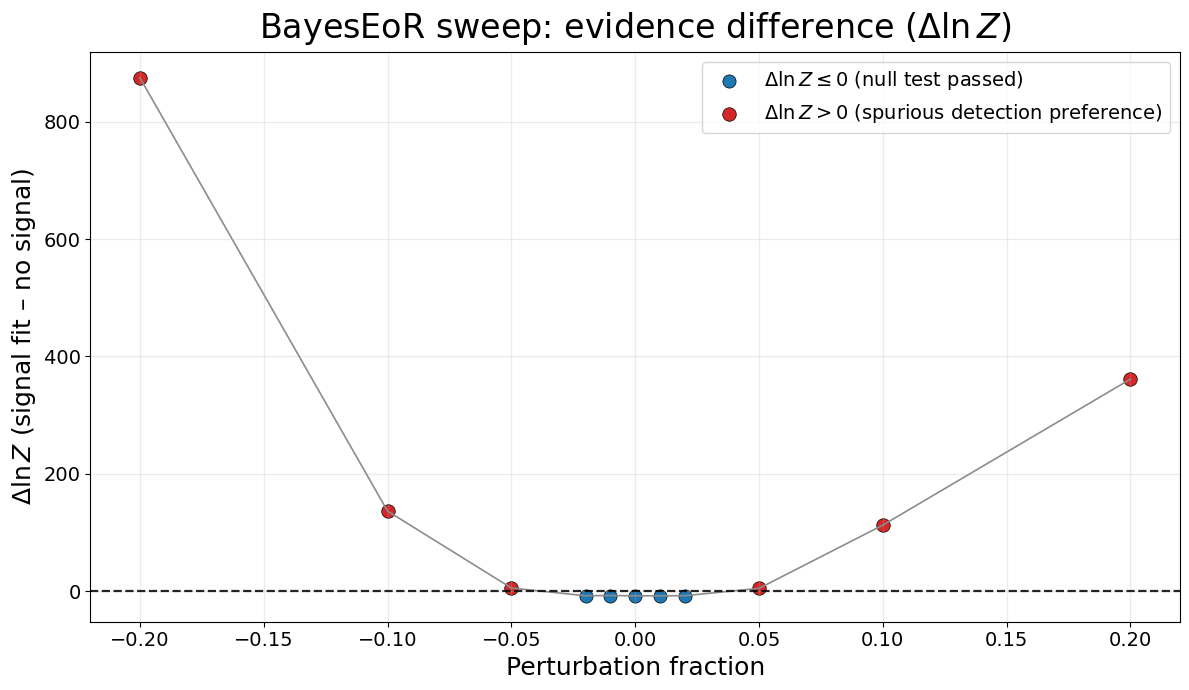

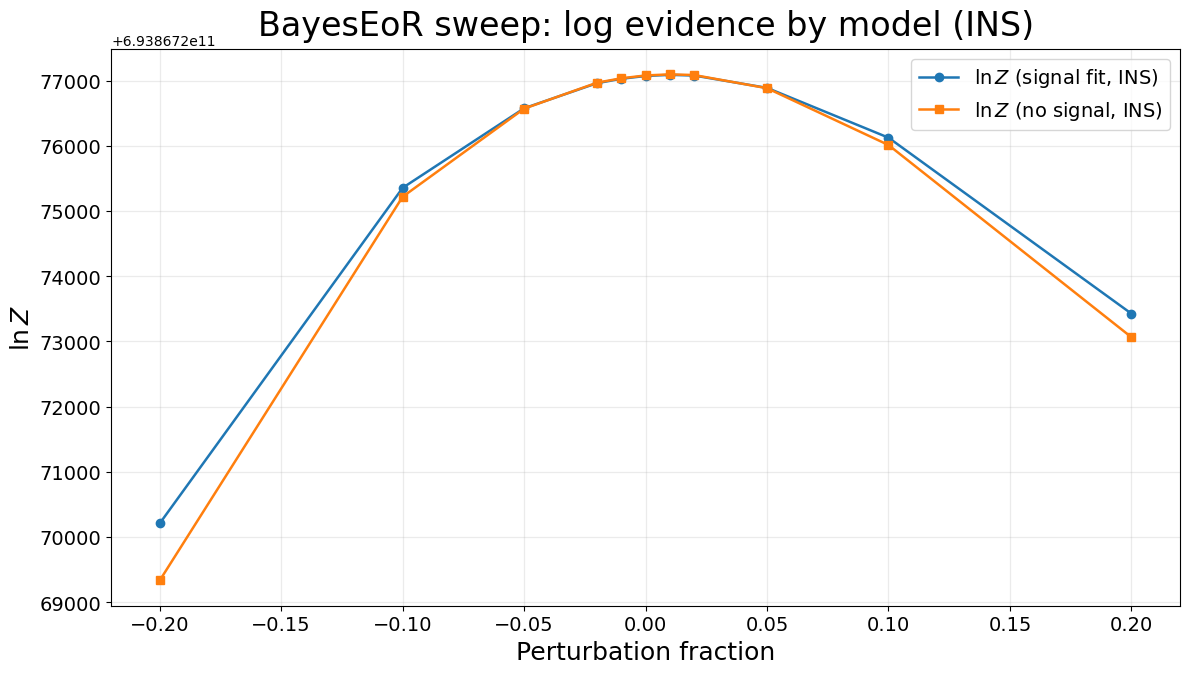

In [5]:
# Updated Airy sweep summary plotting from report outputs (refactored workflow)
payload, report_df = plot_report_summary_diagnostics(
    sweep_dir=sweep_dir,
    title_fs=24,
    axis_fs=18,
    tick_fs=14,
    legend_fs=14,
)

### HERA Beam-FWHM Sensitivity Study  
In this section we explore how mis-modelling the beam’s Full‐Width at Half‐Maximum (FWHM) impacts 21-cm power spectrum inference. Using foreground-only validation datasets, we systematically vary the forward‐modelling beam FWHM by ±0.1%, ±1%, ±2%, ±5%, ±10%, and ±20%, and examine the recovered posteriors.

> **Key validation logic**: If the pipeline recovers a statistically significant non-zero 21-cm signal (a “detection”) from a pure foreground-only dataset, this indicates a **failure** of the validation test.  
> Conversely, if the posterior is consistent with zero (or with the expected noise baseline), the model passes for that beam-error level.

#### Workflow  
- Build signal-fit chain mappings from each sweep point directory.  
- Use `BeamAnalysisPlotter.plot_analysis_results()` to generate a direct in-notebook chain-comparison figure.  
- Compare scenarios against the expected baseline and inspect fractional-difference behavior.

#### Interpretation  
We identify the maximum beam-width error for which the validation test still **passes**. That threshold informs the instrument modelling budget: beam-width knowledge must be better than that threshold to avoid spurious detections.


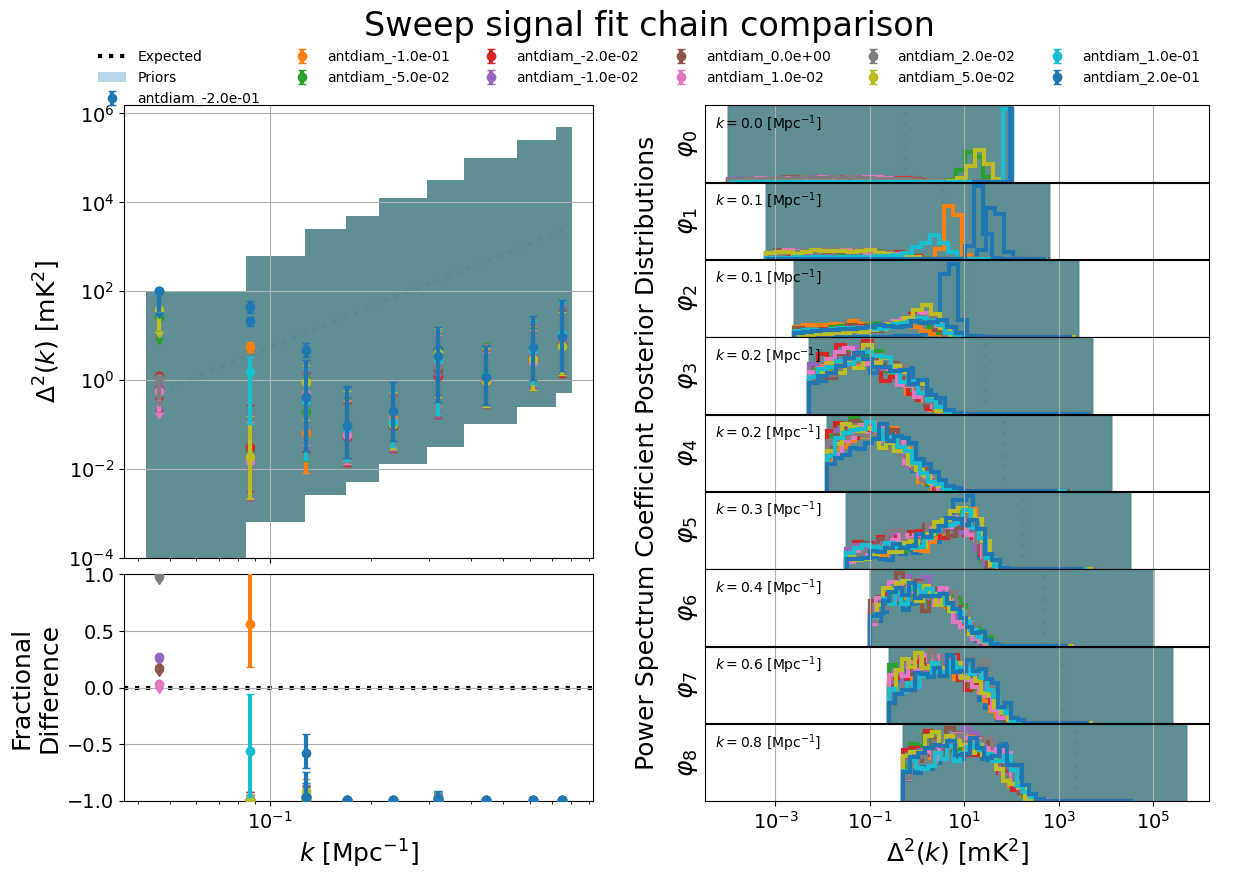

In [6]:
# Build the complementary signal-fit chain comparison figure directly in notebook.
fig = plot_signal_fit_chain_comparison(
    points=points,
    title="Sweep signal fit chain comparison",
    title_fs=24,
    axis_fs=18,
    tick_fs=14,
    legend_fs=11,
)

### BaNTER (Bayesian Evidence Null-Test Evidence Ratio) Analysis  
Here we compute the **BaNTER statistic**, comparing Bayesian evidences between:
- *Model 1*: foreground + EoR (`signal fit`)  
- *Model 2*: foreground-only (`no signal`)  

For this Airy sweep, the pair mapping is built from `sweep_manifest.json` run directories (not `find_chain_pairs` over `GL_*` directory names).

#### Workflow  
- Build point-level `ChainPair` objects from each sweep point (`run_dir/output/signal_fit` vs `run_dir/output/no_signal`).  
- Run `run_complete_bayeseor_analysis()` across those pairs.  
- Present a plain-language summary where perturbations are rendered in plain English and interpretations are phrased in inference language.

#### Interpretation language used below  
- Positive log Bayes factor: **Strong evidence for spurious power detected** (validation fail).  
- Negative log Bayes factor: **Unbiased inferences recovered** (validation pass).

In [7]:
# Airy sweep BaNTER summary via reusable helper
banter = run_airy_banter_summary(points=points)
airy_pairs = banter["airy_pairs"]
results = banter["results"]
summary_df = banter["summary_df"]

Found 11 valid Airy chain pairs
Example keys: ['antdiam_-2.0e-01', 'antdiam_-1.0e-01', 'antdiam_-5.0e-02', 'antdiam_-2.0e-02', 'antdiam_-1.0e-02']
COMPLETE BAYESEOR PERTURBATION ANALYSIS SUMMARY (AIRY, PLAIN-LANGUAGE)


perturbation,log_bayes_factor,validation,interpretation
ΔD/D = -20.00%,875.681274,❌ FAIL,Strong evidence for spurious power detected
ΔD/D = -10.00%,138.156250,❌ FAIL,Strong evidence for spurious power detected
ΔD/D = -5.00%,7.129150,❌ FAIL,Strong evidence for spurious power detected
ΔD/D = -2.00%,-6.075195,✅ PASS,Unbiased inferences recovered
ΔD/D = -1.00%,-6.090942,✅ PASS,Unbiased inferences recovered
ΔD/D = +0.00%,-6.424683,✅ PASS,Unbiased inferences recovered
ΔD/D = +1.00%,-6.684448,✅ PASS,Unbiased inferences recovered
ΔD/D = +2.00%,-6.565430,✅ PASS,Unbiased inferences recovered
ΔD/D = +5.00%,6.078003,❌ FAIL,Strong evidence for spurious power detected
ΔD/D = +10.00%,113.918457,❌ FAIL,Strong evidence for spurious power detected


TOTAL: 11 | PASS: 5 | FAIL: 6 | ERROR: 0


## Summary & Conclusions  
- In the GSM + GLEAM beam-FWHM sensitivity analysis, the pipeline remains **robust** for beam-width errors up to ±2%, which is a lower tolerance than in the lower-fidelity GSM-only and GSM+GLEAM Gaussian-beam analyses.  
- Beyond that threshold, the validation test fails due to spurious power-spectrum detections or excessively large Bayes factors.  
- Recommended next steps:  
  1. Extend the analysis to include realistic beam-error distributions and, possibly, EM simulations of the beam.  
  2. Incorporate full simulation-to-inference chain variations (e.g., baseline errors, calibration offsets).  
- **Implication for the instrument-validation workflow**: Under the approximations made here, beam width must be known to ±2% (or better) to ensure reliable EoR inference in forward-modelling analyses of HERA-style arrays.

## How to Re-use This Notebook  
- Configure runtime paths so `paths.chains_dir` resolves to your local sweep outputs.  
- Ensure the sweep report summary JSON exists before running summary-plot cells (for example via `valska-bayeseor-report-all`).  
- Use `BeamAnalysisPlotter.plot_analysis_results()` and `run_complete_bayeseor_analysis()` as templates for additional error scenarios.  
- Save figures and Bayes-factor summaries for your project.
